In [1]:
import pandas as pd 
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt

# Разведочный анализ

In [2]:
df = pd.read_csv('gym_churn.csv')

In [3]:
df

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.406023,12.0,8,2.284497,2.349070,0
3996,0,1,0,0,1,1,1,29,68.883764,1.0,1,1.277168,0.292859,1
3997,1,1,1,1,1,12,0,28,78.250542,11.0,2,2.786146,2.831439,0
3998,0,1,1,1,1,6,0,32,61.912657,5.0,3,1.630108,1.596237,0


In [4]:
# переводим все колонки в нижний регистр 
df.columns = df.columns.str.lower()


In [5]:
# делаем 2 датафрейма по условию оттока
df_churn = df.query('churn == 1').reset_index(drop=True)
df_not_churn = df.query('churn == 0').reset_index(drop=True)

In [6]:
# клиенты, которые перестали пользоваться услугами зала
df_churn

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
0,0,1,0,0,1,1,0,30,217.786641,1.0,0,1.213502,1.049387,1
1,1,1,1,0,1,1,0,27,266.783824,1.0,2,2.348535,1.584316,1
2,1,1,0,0,1,1,1,27,152.748668,1.0,1,0.000000,0.000000,1
3,0,0,0,0,1,1,0,30,153.198594,1.0,3,0.636382,0.000000,1
4,1,1,0,0,1,1,1,32,276.079882,1.0,1,1.420637,1.043101,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1056,1,1,0,0,1,1,0,24,135.395712,1.0,0,1.390251,0.789321,1
1057,1,1,0,0,1,6,1,22,101.107544,6.0,2,1.377860,0.343915,1
1058,0,1,1,1,1,1,1,34,226.804845,1.0,0,1.399529,0.304130,1
1059,1,1,0,0,1,1,0,26,31.066721,1.0,1,1.157451,0.269597,1


In [7]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             1061 non-null   int64  
 1   near_location                      1061 non-null   int64  
 2   partner                            1061 non-null   int64  
 3   promo_friends                      1061 non-null   int64  
 4   phone                              1061 non-null   int64  
 5   contract_period                    1061 non-null   int64  
 6   group_visits                       1061 non-null   int64  
 7   age                                1061 non-null   int64  
 8   avg_additional_charges_total       1061 non-null   float64
 9   month_to_end_contract              1061 non-null   float64
 10  lifetime                           1061 non-null   int64  
 11  avg_class_frequency_total          1061 non-null   float

In [8]:
df_churn.describe()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
count,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.0
mean,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546,1.0
std,0.500118,0.422217,0.478837,0.387495,0.296204,2.132371,0.443448,2.895163,77.696419,1.964593,1.110799,0.694705,0.770237,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,1.0
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,25.000000,50.629127,1.000000,0.000000,1.010771,0.421337,1.0
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,103.814686,1.000000,1.000000,1.491187,0.979445,1.0
75%,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,29.000000,165.616858,1.000000,1.000000,1.956438,1.588576,1.0
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,38.000000,425.535220,12.000000,9.000000,3.478646,3.540271,1.0


In [9]:
# распределение клиентов по длительности абонемента
df_co = df_churn.groupby('contract_period',as_index=False) \
    .agg({'gender':'count'}).rename(columns={'gender':'number_of_clients'})

/var/folders/_q/y78js8613z37pq4ldhx06pc00000gn/T/ipykernel_26712/367468935.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='contract_period', y='number_of_clients',data=df_co, palette=['lightgreen','lightblue','red'])


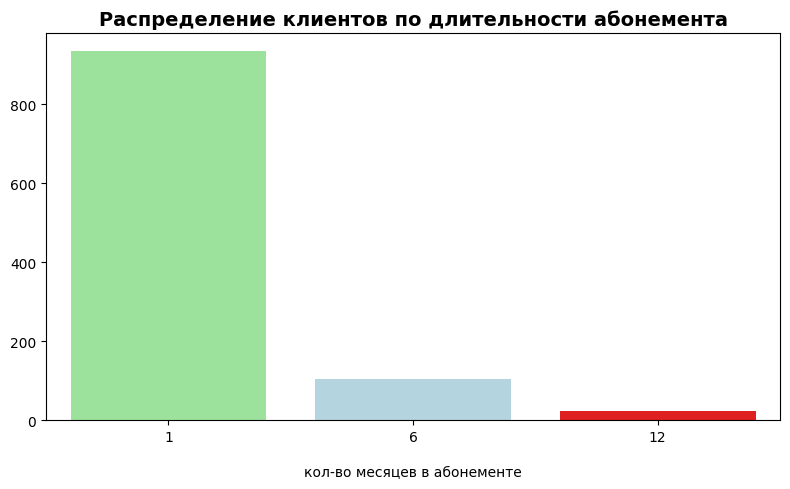

In [10]:
# визуализация 
plt.figure(figsize=(8,5))
sns.barplot(x='contract_period', y='number_of_clients',data=df_co, palette=['lightgreen','lightblue','red'])
plt.xlabel('кол-во месяцев в абонементе',labelpad=15)
plt.ylabel('')
plt.title('Распределение клиентов по длительности абонемента',fontdict={'fontsize':14,'fontweight':'bold'})
plt.tight_layout()
plt.show()

In [11]:
# распределение клиентов мужчина/женщина
df_g = df_churn.groupby('gender',as_index=False) \
    .agg({'partner':'count'}).rename(columns={'partner':'number_of_clients'})
df_g['gender'] = df_g['gender'].replace({0: 'женщины', 1: 'мужчины'})

/var/folders/_q/y78js8613z37pq4ldhx06pc00000gn/T/ipykernel_26712/3437265360.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gender', y='number_of_clients',data=df_g, palette=['lightgreen','lightblue'])


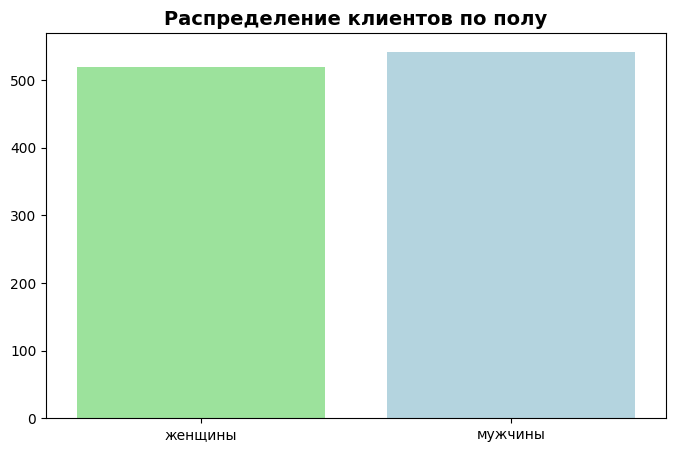

In [12]:
# визуализация 
plt.figure(figsize=(8,5))
sns.barplot(x='gender', y='number_of_clients',data=df_g, palette=['lightgreen','lightblue'])
plt.ylabel('')
plt.xlabel('')
plt.title('Распределение клиентов по полу',fontdict={'fontsize':14,'fontweight':'bold'})
plt.show()


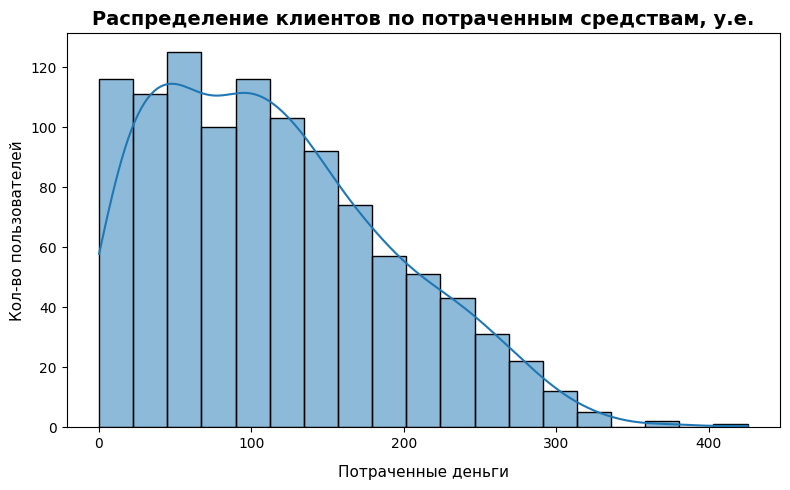

In [13]:
# визуализация
plt.figure(figsize=(8,5))
sns.histplot(df_churn['avg_additional_charges_total'],kde=True)
plt.ylabel('Кол-во пользователей',fontsize=11)
plt.xlabel('Потраченные деньги',labelpad=10,fontsize=11)
plt.title('Распределение клиентов по потраченным средствам, у.е.',fontdict={'fontsize':14,'fontweight':'bold'})
plt.tight_layout()
plt.show()

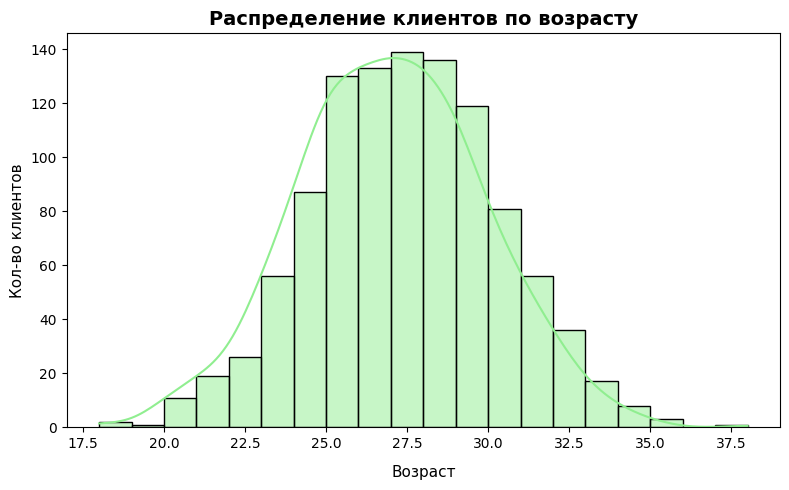

In [14]:
# визуализация
plt.figure(figsize=(8,5))
sns.histplot(df_churn['age'],bins=20,color='lightgreen',kde=True)
plt.ylabel('Кол-во клиентов',fontsize=11)
plt.xlabel('Возраст',labelpad=10,fontsize=11)
plt.title('Распределение клиентов по возрасту',fontdict={'fontsize':14,'fontweight':'bold'})
plt.tight_layout()
plt.show()

In [15]:
# клиенты, которые все еще пользуются услугами зала
df_not_churn

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2934,0,1,1,0,1,1,0,33,231.778628,1.0,3,1.418791,1.450442,0
2935,1,1,1,0,1,12,0,33,2.406023,12.0,8,2.284497,2.349070,0
2936,1,1,1,1,1,12,0,28,78.250542,11.0,2,2.786146,2.831439,0
2937,0,1,1,1,1,6,0,32,61.912657,5.0,3,1.630108,1.596237,0


In [16]:
df_not_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2939 entries, 0 to 2938
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             2939 non-null   int64  
 1   near_location                      2939 non-null   int64  
 2   partner                            2939 non-null   int64  
 3   promo_friends                      2939 non-null   int64  
 4   phone                              2939 non-null   int64  
 5   contract_period                    2939 non-null   int64  
 6   group_visits                       2939 non-null   int64  
 7   age                                2939 non-null   int64  
 8   avg_additional_charges_total       2939 non-null   float64
 9   month_to_end_contract              2939 non-null   float64
 10  lifetime                           2939 non-null   int64  
 11  avg_class_frequency_total          2939 non-null   float

In [17]:
df_not_churn.describe()


,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
count,2939.000000,2939.000000,2939.000000,2939.000000,2939.000000,2939.000000,2939.000000,2939.000000,2939.000000,2939.000000,2939.000000,2939.000000,2939.000000,2939.0
mean,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882,0.0
std,0.499984,0.332933,0.498914,0.478144,0.295040,4.716942,0.498795,3.009933,99.801599,4.363522,3.874780,1.016006,1.018994,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,19.000000,0.171862,1.000000,0.000000,0.000000,0.000000,0.0
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,28.000000,76.920993,1.000000,2.000000,1.283137,1.297021,0.0
50%,1.000000,1.000000,1.000000,0.000000,1.000000,6.000000,0.000000,30.000000,149.881171,6.000000,4.000000,2.043252,2.046697,0.0
75%,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,32.000000,224.448274,10.000000,6.000000,2.732944,2.740648,0.0
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,0.0


In [18]:
# распределение клиентов по длительности абонемента
df_co = df_not_churn.groupby('contract_period',as_index=False) \
    .agg({'gender':'count'}).rename(columns={'gender':'number_of_clients'})

/var/folders/_q/y78js8613z37pq4ldhx06pc00000gn/T/ipykernel_26712/367468935.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='contract_period', y='number_of_clients',data=df_co, palette=['lightgreen','lightblue','red'])


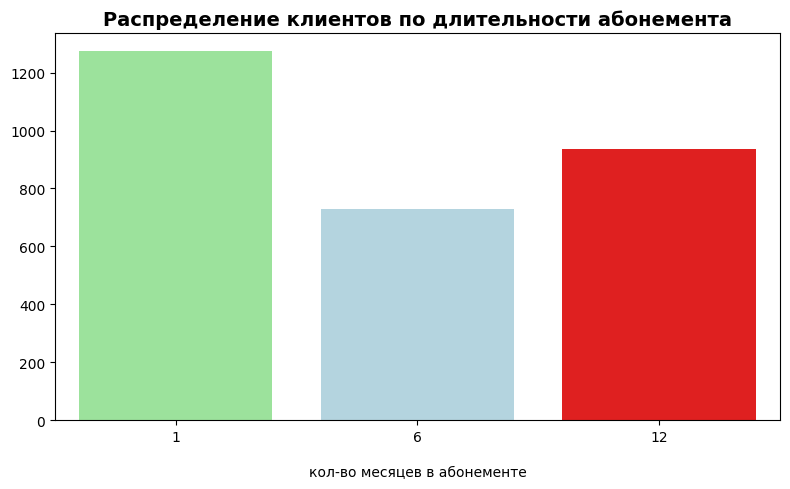

In [19]:
# визуализация 
plt.figure(figsize=(8,5))
sns.barplot(x='contract_period', y='number_of_clients',data=df_co, palette=['lightgreen','lightblue','red'])
plt.xlabel('кол-во месяцев в абонементе',labelpad=15)
plt.ylabel('')
plt.title('Распределение клиентов по длительности абонемента',fontdict={'fontsize':14,'fontweight':'bold'})
plt.tight_layout()
plt.show()

In [20]:
# распределение клиентов мужчина/женщина
df_g = df_not_churn.groupby('gender',as_index=False) \
    .agg({'partner':'count'}).rename(columns={'partner':'number_of_clients'})
df_g['gender'] = df_g['gender'].replace({0: 'женщины', 1: 'мужчины'})

/var/folders/_q/y78js8613z37pq4ldhx06pc00000gn/T/ipykernel_26712/4019214208.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gender', y='number_of_clients',data=df_g, palette=['lightgreen','lightblue'])


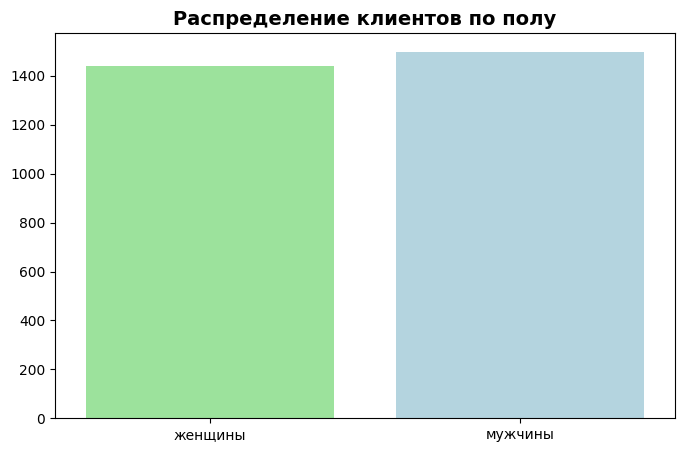

In [21]:
# визуализация 
plt.figure(figsize=(8,5))
sns.barplot(x='gender', y='number_of_clients',data=df_g, palette=['lightgreen','lightblue'])
plt.ylabel('')
plt.xlabel('')
plt.title('Распределение клиентов по полу',fontdict={'fontsize':14,'fontweight':'bold'})
plt.show()

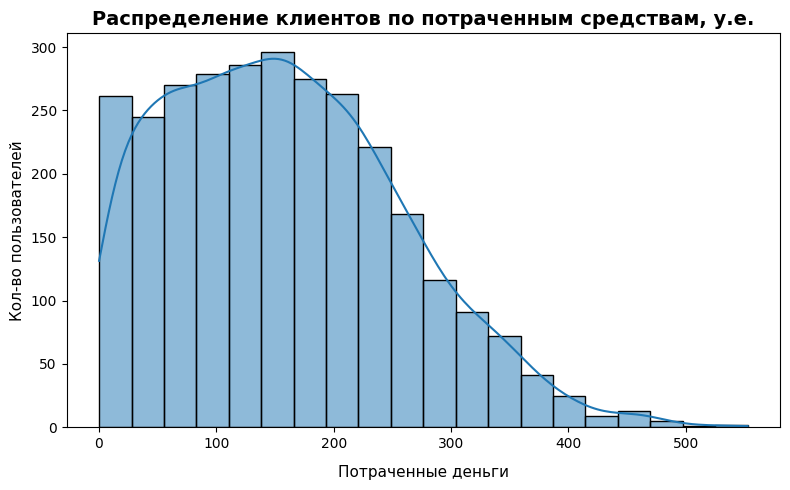

In [22]:
# визуализация
plt.figure(figsize=(8,5))
sns.histplot(df_not_churn['avg_additional_charges_total'],kde=True,bins=20)
plt.ylabel('Кол-во пользователей',fontsize=11)
plt.xlabel('Потраченные деньги',labelpad=10,fontsize=11)
plt.title('Распределение клиентов по потраченным средствам, у.е.',fontdict={'fontsize':14,'fontweight':'bold'})
plt.tight_layout()
plt.show()

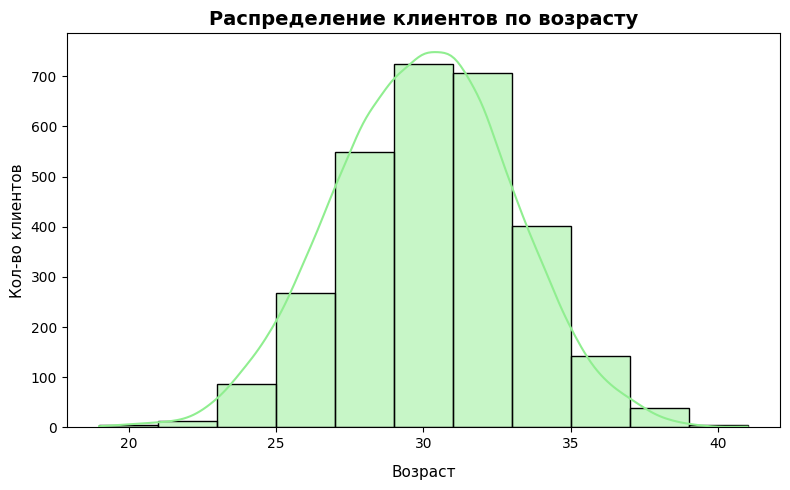

In [23]:
# визуализация
plt.figure(figsize=(8,5))
sns.histplot(df_not_churn['age'],bins=11,color='lightgreen',kde=True)
plt.ylabel('Кол-во клиентов',fontsize=11)
plt.xlabel('Возраст',labelpad=10,fontsize=11)
plt.title('Распределение клиентов по возрасту',fontdict={'fontsize':14,'fontweight':'bold'})
plt.tight_layout()
plt.show()

In [24]:
# корреляция 
df_not_churn.corr()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
gender,1.000000,0.004588,-0.017409,-0.002746,-0.008443,-0.002893,0.015434,0.014745,-0.013551,-0.005047,0.019150,0.018719,0.017506,NaN
near_location,0.004588,1.000000,-0.015871,0.198554,-0.013571,0.130844,0.147798,0.006876,0.023125,0.122438,0.022296,0.001698,0.000975,NaN
partner,-0.017409,-0.015871,1.000000,0.455108,0.021220,0.294745,-0.011820,-0.011818,-0.006994,0.280882,-0.013123,-0.019247,-0.020797,NaN
promo_friends,-0.002746,0.198554,0.455108,1.000000,-0.004713,0.217869,0.099610,-0.012915,-0.003494,0.212872,0.003754,-0.012794,-0.012416,NaN
phone,-0.008443,-0.013571,0.021220,-0.004713,1.000000,-0.007959,0.000789,-0.011362,0.004559,-0.012660,-0.026664,0.018325,0.019386,NaN
contract_period,-0.002893,0.130844,0.294745,0.217869,-0.007959,1.000000,0.126558,-0.021563,0.039649,0.967340,-0.001045,-0.006538,-0.005080,NaN
group_visits,0.015434,0.147798,-0.011820,0.099610,0.000789,0.126558,1.000000,0.015875,0.001929,0.118517,0.002835,0.005587,0.003851,NaN
age,0.014745,0.006876,-0.011818,-0.012915,-0.011362,-0.021563,0.015875,1.000000,-0.001919,-0.020407,-0.024132,0.023803,0.022948,NaN
avg_additional_charges_total,-0.013551,0.023125,-0.006994,-0.003494,0.004559,0.039649,0.001929,-0.001919,1.000000,0.044765,-0.007366,-0.006934,-0.004487,NaN
month_to_end_contract,-0.005047,0.122438,0.280882,0.212872,-0.012660,0.967340,0.118517,-0.020407,0.044765,1.000000,-0.008097,-0.016365,-0.015420,NaN


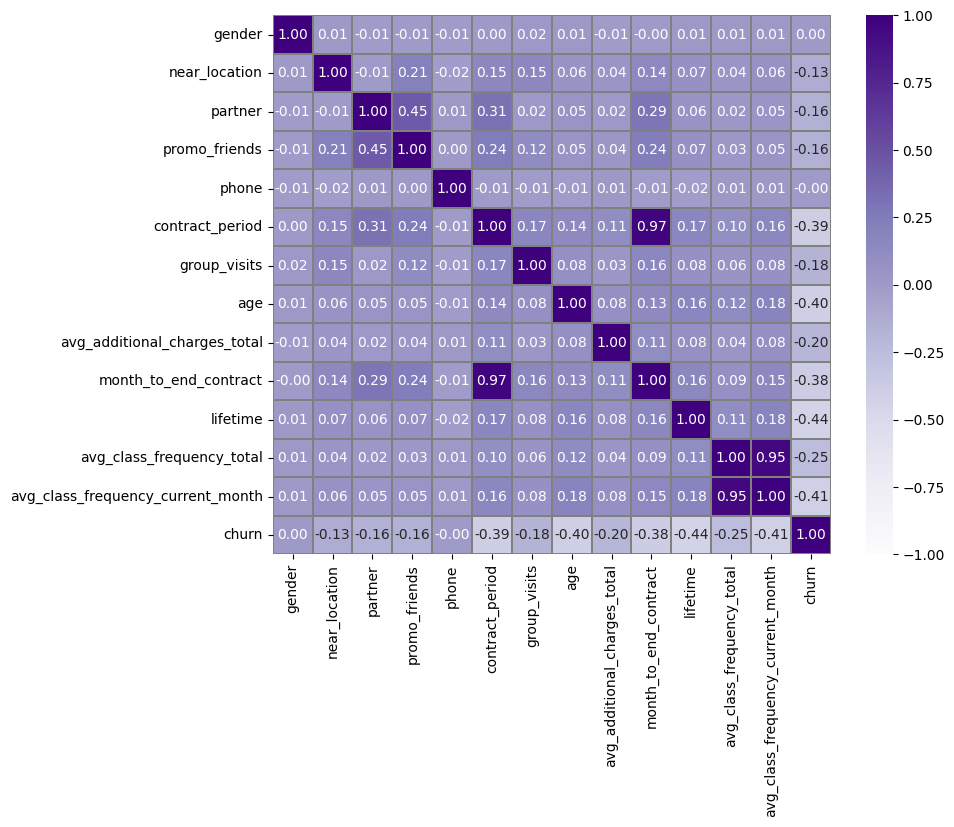

In [25]:
# матрица корреляции
plt.figure(figsize=(9,7))
sns.heatmap(df.corr(),vmin=-1,vmax=1,annot=True,fmt='.2f',cmap='Purples',linewidths=0.1,linecolor='grey')
plt.show()

# Логистическая регрессия

In [26]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score,r2_score
from scipy.cluster.hierarchy import linkage,dendrogram
from sklearn.cluster import KMeans


In [27]:
# делим данные на целевую метрику и признаки
X = df.drop(['churn'], axis=1)
y = df['churn']

In [28]:
# разделяем данные на тренировочную/тестовую выборку
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=0)

In [29]:
# стандартизируем данные 
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [30]:
# Логистическая регрессия
model = LogisticRegression(random_state=0).fit(X_train,y_train)

In [31]:
# прогнозируем
y_pred = model.predict(X_test)

In [32]:
# Оценка точности
print(f'Accuracy score: {accuracy_score(y_test,y_pred)}')
print(f'Precision score: {round(precision_score(y_test, y_pred),2)}')
print(f'Recall score: {round(recall_score(y_test, y_pred),2)}')

Accuracy score: 0.925
Precision score: 0.86
Recall score: 0.85


# Ансамбль деревьев

In [33]:
rf_model = RandomForestClassifier(random_state=0,n_estimators=100,min_samples_split=5,max_depth=10).fit(X_train,y_train)

In [34]:
# прогнозируем
y_pred_rf = rf_model.predict(X_test)

In [35]:
# Оценка точности
print(f'Accuracy score: {accuracy_score(y_test,y_pred_rf)}')
print(f'Precision score: {round(precision_score(y_test, y_pred_rf),2)}')
print(f'Recall score: {round(recall_score(y_test, y_pred_rf),2)}')

Accuracy score: 0.919
Precision score: 0.87
Recall score: 0.82


# Кластеризация пользователей

In [36]:
X_c = sc.fit_transform(X_train)

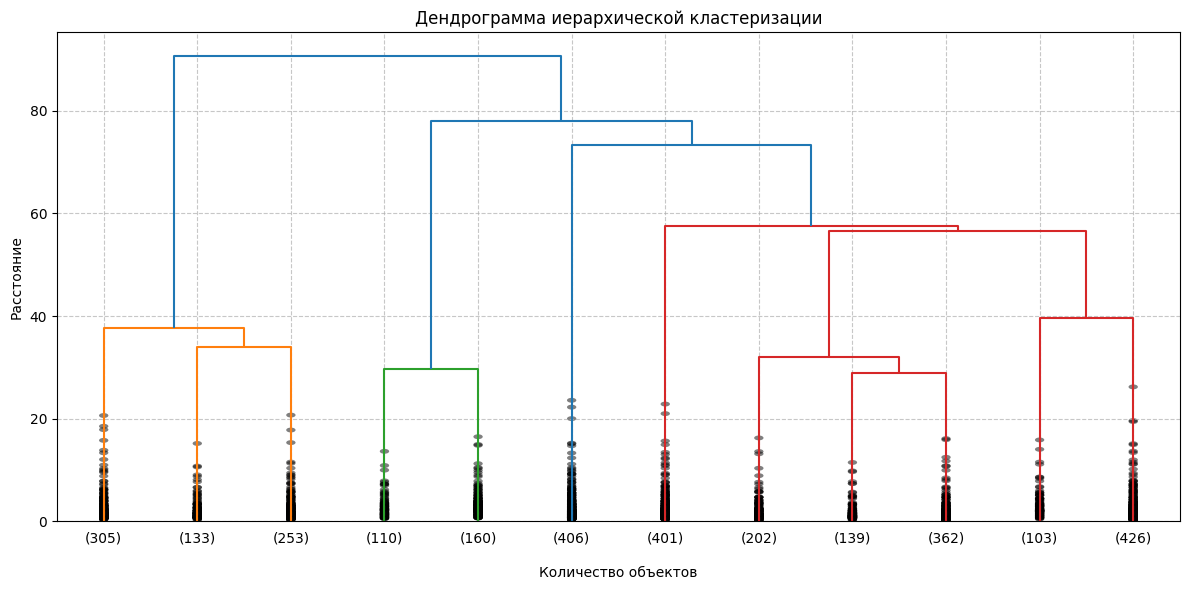

In [37]:
# дендограмма
Z = linkage(X_train, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(Z,
          truncate_mode='lastp',  
          p=12,                   
          show_leaf_counts=True,       
          leaf_font_size=10,      
          show_contracted=True)   

plt.title('Дендрограмма иерархической кластеризации')
plt.xlabel('Количество объектов',labelpad=15)
plt.ylabel('Расстояние')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [38]:
# определяем оптимальное число класстеров 
distances = Z[:, 2]  # расстояния при объединении

diff = np.diff(distances)
optimal_idx = np.argmax(diff) + 1  
optimal_clusters = len(distances) - optimal_idx + 1

print(f"Оптимальное число кластеров: {optimal_clusters}")

Оптимальное число кластеров: 6


In [39]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)  

# Кластеризация на тренировочных данных
kmeans = KMeans(n_clusters=6, init='k-means++', random_state=0)
kmeans.fit(X_train_scaled)

# Предсказание для тестовых данных 
test_clusters = kmeans.predict(X_test_scaled)
train_clusters = kmeans.labels_
train_clusters

array([1, 0, 2, ..., 1, 1, 0], shape=(3000,), dtype=int32)

In [40]:
X_train_with_clusters = X_train.copy()
X_train_with_clusters['cluster'] = train_clusters

# Группируем по кластерам и считаем средние
cluster_means_train = X_train_with_clusters.groupby('cluster').mean()
print("Средние значения признаков по кластерам (тренировочные данные):")
cluster_means_train

Средние значения признаков по кластерам (тренировочные данные):


,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month
cluster,,,,,,,,,,,,,
0,0.513314,0.951183,0.751479,0.504438,0.908284,11.955621,0.573964,29.872781,165.189863,10.955621,4.727811,1.931006,1.924020
1,0.490818,1.000000,0.212020,0.023372,0.908180,1.764608,0.181970,26.899833,110.037566,1.707846,1.666110,1.381492,1.064950
2,0.596026,0.955850,0.390728,0.218543,0.896247,3.496689,0.432671,30.002208,146.962306,3.108168,5.013245,3.233842,3.243705
3,0.484772,0.000000,0.456853,0.071066,0.918782,2.393401,0.223350,28.515228,133.434316,2.246193,2.926396,1.701799,1.511149
4,0.471963,0.997664,0.235981,0.011682,0.915888,2.544393,0.642523,30.897196,187.310999,2.404206,4.904206,1.513353,1.467612
5,0.482222,1.000000,0.808889,1.000000,0.915556,3.000000,0.457778,29.042222,141.624569,2.826667,3.237778,1.605275,1.472280


In [41]:
X_test_with_clusters = X_test.copy()
X_test_with_clusters['cluster'] = test_clusters

cluster_means_test = X_test_with_clusters.groupby('cluster').mean()
print("Средние значения признаков по кластерам (тестовые данные):")
cluster_means_test

Средние значения признаков по кластерам (тестовые данные):


,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month
cluster,,,,,,,,,,,,,
0,0.480519,0.943723,0.722944,0.502165,0.874459,11.870130,0.489177,29.956710,163.840378,10.909091,4.878788,2.024886,2.007037
1,0.513812,1.000000,0.276243,0.027624,0.867403,1.552486,0.193370,27.082873,113.423321,1.480663,1.546961,1.429904,1.134157
2,0.624113,0.971631,0.354610,0.205674,0.900709,3.397163,0.375887,30.255319,154.789283,3.120567,4.723404,3.191275,3.219208
3,0.532468,0.000000,0.480519,0.090909,0.909091,2.000000,0.188312,28.415584,134.252459,1.837662,2.545455,1.564544,1.379191
4,0.487805,1.000000,0.250000,0.024390,0.890244,2.469512,0.603659,31.018293,175.743876,2.335366,5.030488,1.566672,1.505757
5,0.511628,1.000000,0.837209,1.000000,0.868217,3.139535,0.449612,29.147287,135.255360,2.899225,3.372093,1.575753,1.488791


In [42]:
# Создаем DataFrame только с кластерами и оттоком для тестовой выборки
test_analysis = pd.DataFrame({
    'cluster': test_clusters,
    'churn': y_test
})

# Считаем долю оттока по кластерам
churn_analysis = test_analysis.groupby('cluster',as_index=False).agg({'churn':'mean'}).reset_index(drop=True)
churn_analysis['churn'] = churn_analysis['churn'] * 100
churn_analysis

,cluster,churn
0,0,2.597403
1,1,72.375691
2,2,2.836879
3,3,45.454545
4,4,9.756098
5,5,25.581395


### На основании результатов можно сделать вывод, что кластер №1 имееет самый большой отток клиентов, а кластер №0 наименьший

# Выводы:
## - Стоит провести промо акцию, например, скидку на абонемент на 6 и 12 месяцев, так как у большинства клиентов абонемент на 1 месяц, особенно, у тех, кто ушел 
## - Расширить клиентскую базу, именно "возрастной состав", так как большиноство клиентов находятся в диапозоне 25 - 35
## - Добавить новые типы занятий для привлечения клиентов, например, групповые, так как среднее количество занятий маленькое